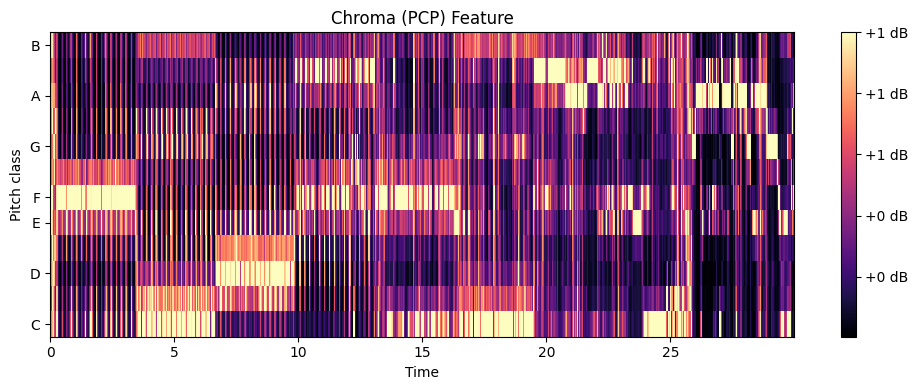

Dominant pitch class (0=C, 1=C#/Db, 2=D, ..., 11=B): 0


In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

song = "../samples/lastfm_samples/audio/b7ae32c12ea0be48d5d29e2337412b9a.mp3"
# 1. Load an audio file (replace 'audio_file.mp3' with your song's file path)
y, sr = librosa.load(song, duration=30)  # load first 30 seconds for example

# 2. Compute the chroma features using STFT (Short-Time Fourier Transform)
# This converts the audio signal into a time-frequency representation,
# and then maps the frequencies to the 12 pitch classes.
chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=512)

# 3. Visualize the chroma feature (PCP)
plt.figure(figsize=(10, 4))
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', 
                         hop_length=512, sr=sr)
plt.title('Chroma (PCP) Feature')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

# 4. (Optional) Detecting a dominant pitch class over time
# For a simple example, we can look at the dominant pitch class in each frame.
dominant_pitches = np.argmax(chroma, axis=0)

# Calculate the most common pitch class over time
from scipy.stats import mode
dominant_mode = mode(dominant_pitches)

print('Dominant pitch class (0=C, 1=C#/Db, 2=D, ..., 11=B):', dominant_mode.mode.item())

